# Examples from pre-trained dataset imagenet1k

### ResNet (careful for the last max pooling layer)

The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is Normal mode.
Try to visualize the layer before : 
 [SelectAdaptivePool2d(pool_type=avg, flatten=Flatten(start_dim=1, end_dim=-1)), Linear(in_features=512, out_features=1000, bias=True)]
Activation Shape:torch.Size([1, 512, 7, 7])
Prediction_logits Shape:torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 69.8% certainty
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 512])
Shape of weighted Combination between gradients and activations: (7, 7, 512)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 1.2098195552825928
jet_color shape: (256, 3)


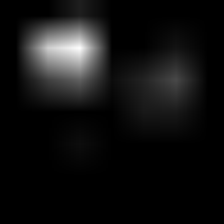

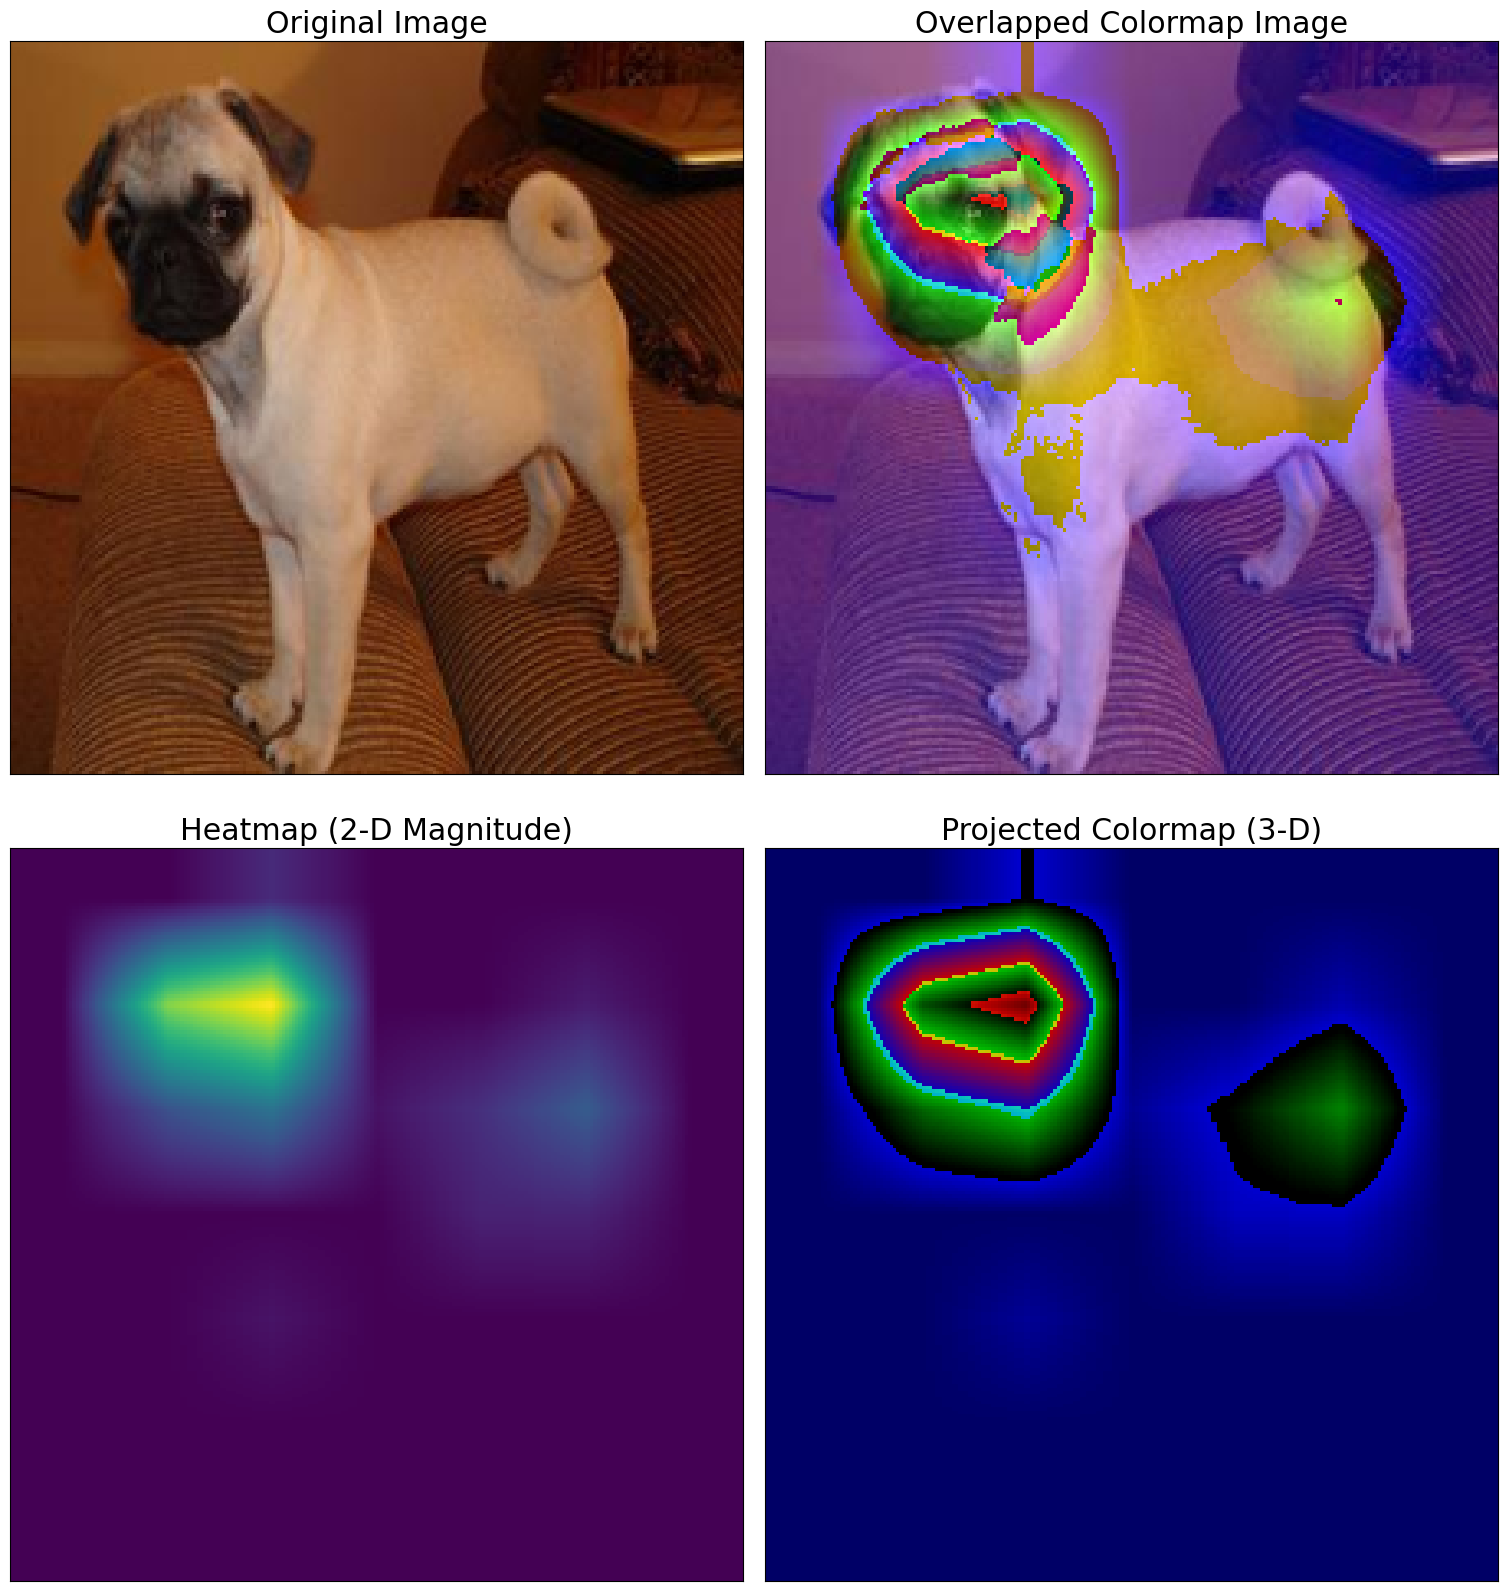

In [1]:
from grad_cam_code.grad_cam import *

#model = create_model('timm/resnet34.a1_in1k', pretrained=True)
model = create_model('timm/resnet18.a1_in1k', pretrained=True)
#model = create_model('timm/resnet10t.c3_in1k', pretrained=True)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'
#img_path = 'graphs/test_images/000000039769.jpg'

# use -1 will raise error since there's a pooling layer before classfication header in ResNet
cam = GradCAM(model,img_path,layer_idx=-2) 
cam(heatmap_threshold=20)
cam.imposing_visualization()
cam.heatmap


### Vision Transformer (ViT) model example

The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is ViT mode.
Try to visualize the layer before : 
 [Linear(in_features=768, out_features=1000, bias=True)]
Activation Shape:torch.Size([1, 196, 768])
Prediction_logits Shape:torch.Size([1, 196, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 85.3% certainty
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 14, 14, 768])
Shape of weighted Combination between gradients and activations: (14, 14, 768)
Shape after channel summation : (14, 14)
Maximum pixel value of heatmap is 0.6154588460922241
jet_color shape: (256, 3)


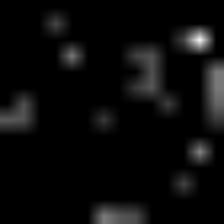

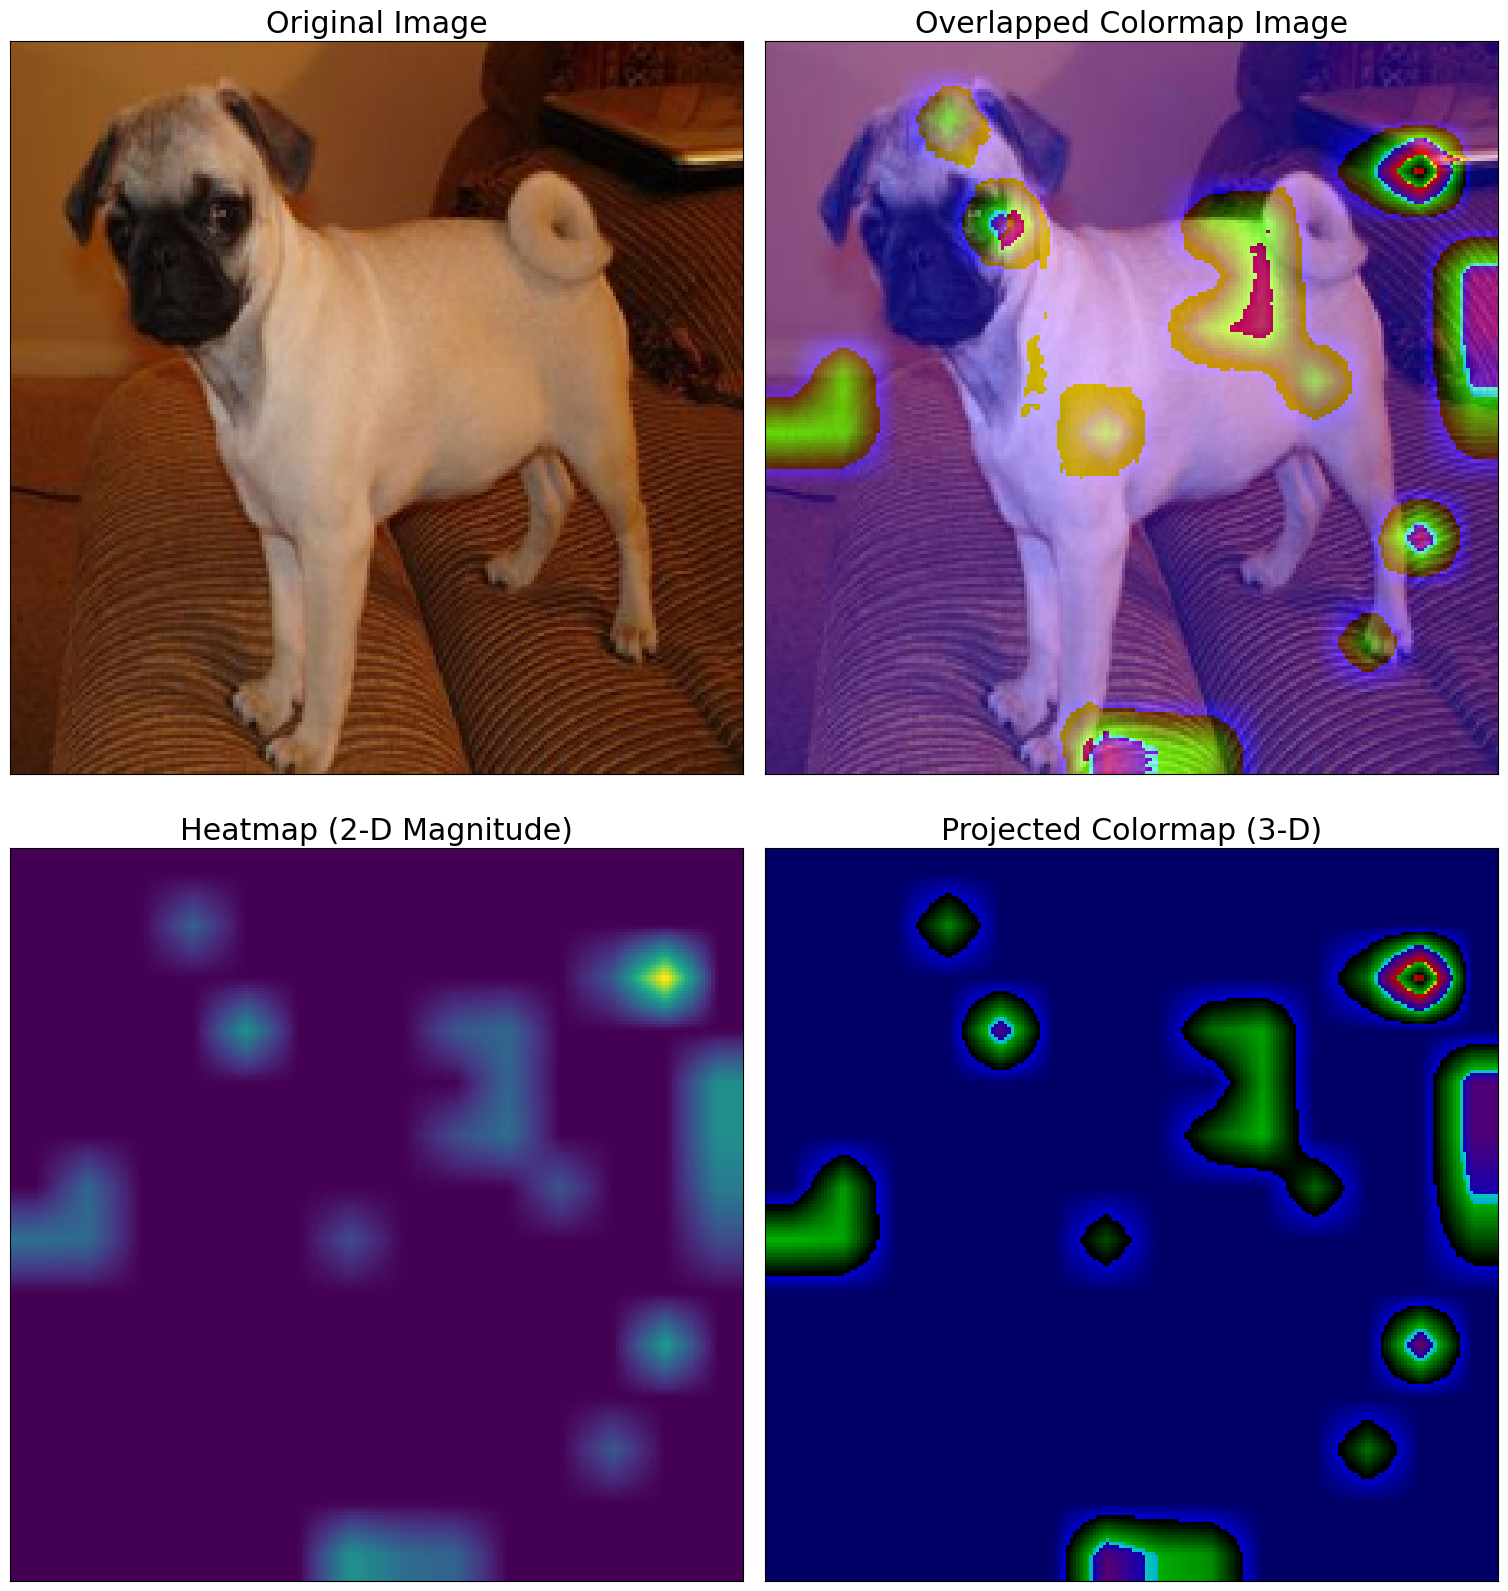

In [2]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config

model = create_model('vit_base_patch16_224', pretrained=True)
## Remember to pass the corresponding preprocessing method, if not using default.
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam_vit = GradCAM(model,img_path, layer_idx=-1, model_type='ViT')
cam_vit(heatmap_threshold=5, transform = transform)
cam_vit.imposing_visualization()
cam_vit.heatmap


The model types you can select from are either
 'Normal' (CNN based), 'ViT', 'SwinT', currently is SwinT mode.
Try to visualize the layer before : 
 [ClassifierHead(
  (global_pool): SelectAdaptivePool2d(pool_type=avg, flatten=Identity())
  (drop): Dropout(p=0.0, inplace=False)
  (fc): Linear(in_features=1024, out_features=1000, bias=True)
  (flatten): Identity()
)]
Activation Shape:torch.Size([1, 7, 7, 1024])
Prediction_logits Shape:torch.Size([1, 1000])
The Grad-CAM will be plotted based on model prediction result: 254 with 81.5% certainty
gradient shape (predictioin logti(s) w.r.t. feature logits): torch.Size([1, 7, 7, 1024])
Shape of weighted Combination between gradients and activations: (7, 7, 1024)
Shape after channel summation : (7, 7)
Maximum pixel value of heatmap is 0.7670761942863464
jet_color shape: (256, 3)


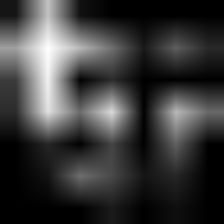

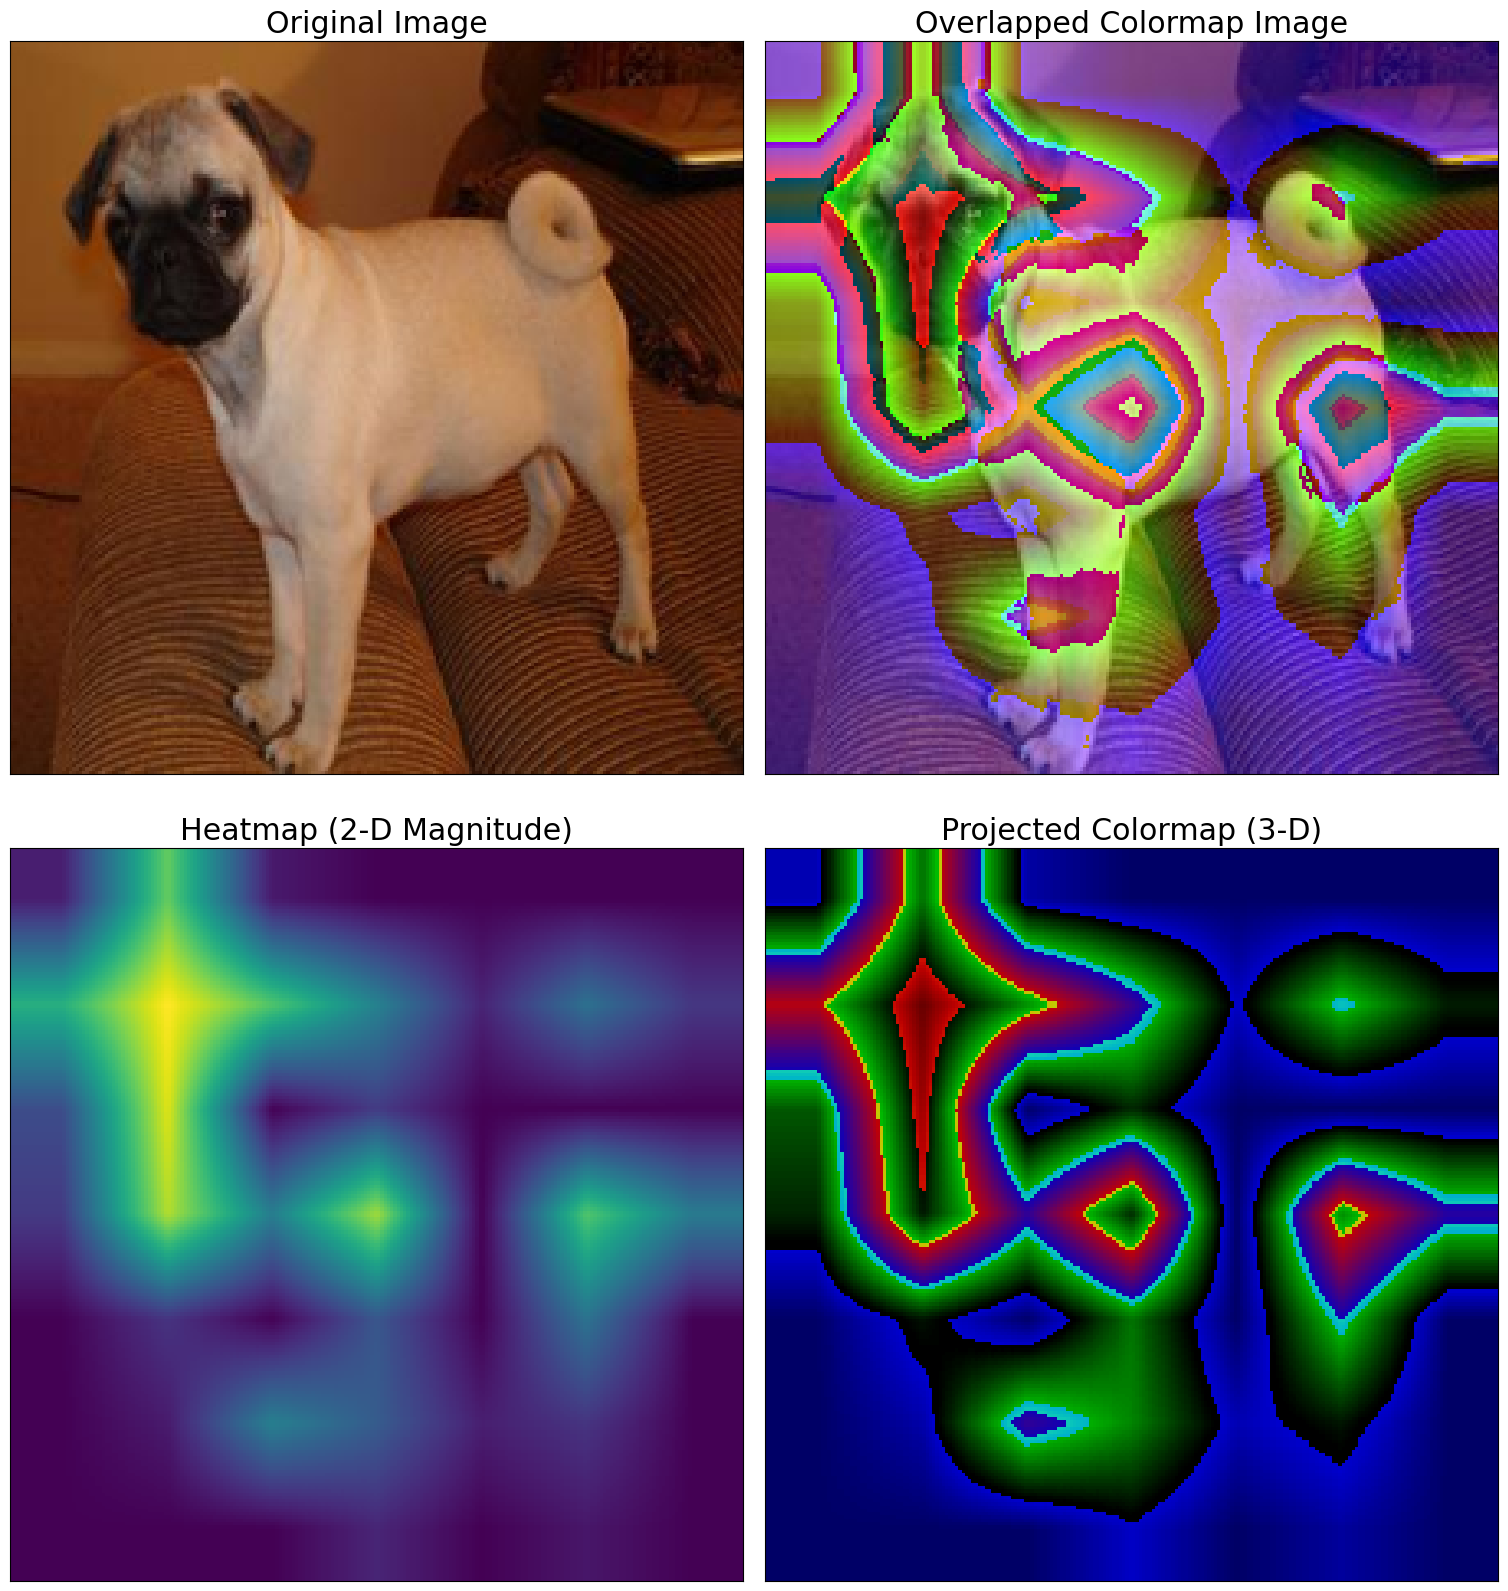

In [3]:
from grad_cam_code.grad_cam import *
from timm.data.transforms_factory import create_transform
from timm.data import resolve_data_config


model = create_model('swin_base_patch4_window7_224', pretrained=True)
config = resolve_data_config({}, model=model)
transform = create_transform(**config)
model.eval()

## Test image samples are from imagenet
img_path = 'graphs/test_images/test2-pug-dog.png'
#img_path = 'graphs/test_images/test4-hotdog.png'

cam = GradCAM(model,img_path,layer_idx=-1, model_type='SwinT', auto_find_classfier=True)
cam(heatmap_threshold=20, transform = transform)
cam.imposing_visualization()
cam.heatmap
